#Funciones de Distribución de Probabilidad

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

##Distribución Uniforme

In [34]:
a = 1
b = 100
n = 10000

(array([1022.,  941.,  976., 1054., 1015.,  953., 1010., 1047.,  981.,
        1001.]),
 array([ 1.00325053, 10.90230159, 20.80135264, 30.7004037 , 40.59945476,
        50.49850581, 60.39755687, 70.29660793, 80.19565898, 90.09471004,
        99.9937611 ]),
 <BarContainer object of 10 artists>)

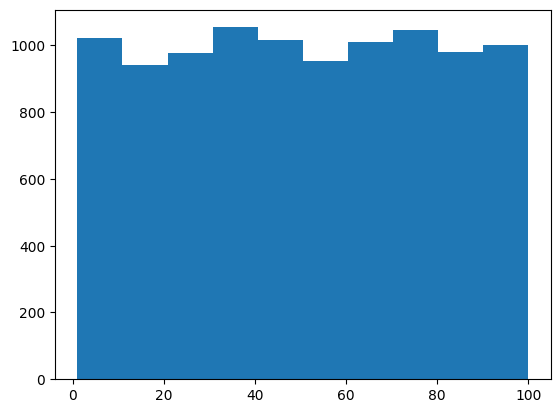

In [35]:
# Obviamente, se aproximará a un rectángulo perfecto en la medida en que se incremente 'n'
data1 = np.random.uniform(a, b, n)
plt.hist(data1)

##Distribución Normal

(array([  29.,  192.,  861., 2151., 2891., 2438., 1116.,  284.,   35.,
           3.]),
 array([-3.51905455, -2.75614648, -1.99323841, -1.23033035, -0.46742228,
         0.29548579,  1.05839385,  1.82130192,  2.58420998,  3.34711805,
         4.11002612]),
 <BarContainer object of 10 artists>)

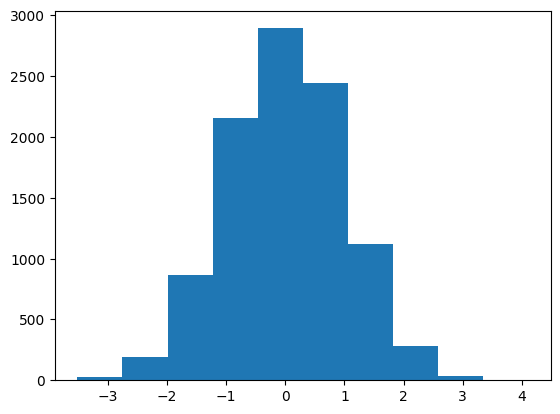

In [36]:
# Se usa el método .randn() para generar una distribución normal estandarizada (media = 0, desviación estándar = 1)
data2 = np.random.randn(n)
plt.hist(data2)

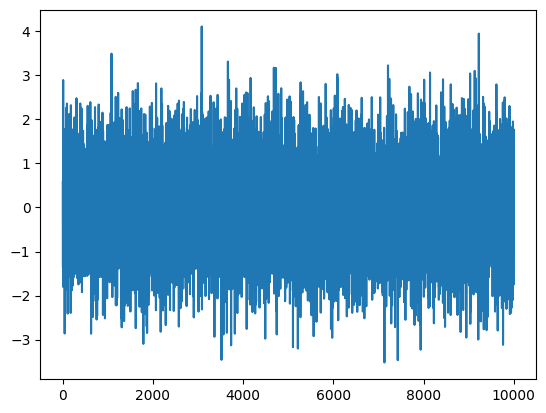

In [37]:
x = range(n)
plt.plot(x, data2)

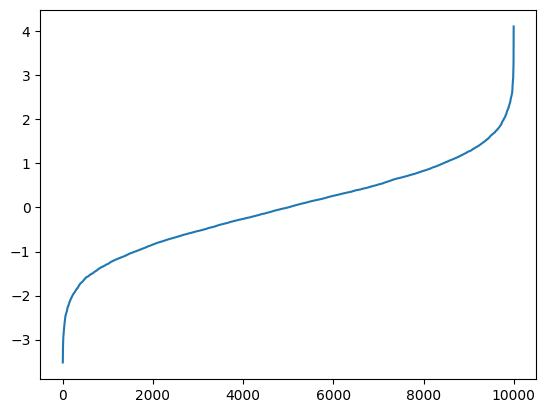

In [39]:
# Visualizamos el gráfico función de la distribución
plt.plot(x,sorted(data2))

(array([  21.,  171.,  659., 1864., 2824., 2537., 1416.,  433.,   67.,
           8.]),
 array([-3.61881305, -1.7240579 ,  0.17069724,  2.06545238,  3.96020752,
         5.85496267,  7.74971781,  9.64447295, 11.53922809, 13.43398324,
        15.32873838]),
 <BarContainer object of 10 artists>)

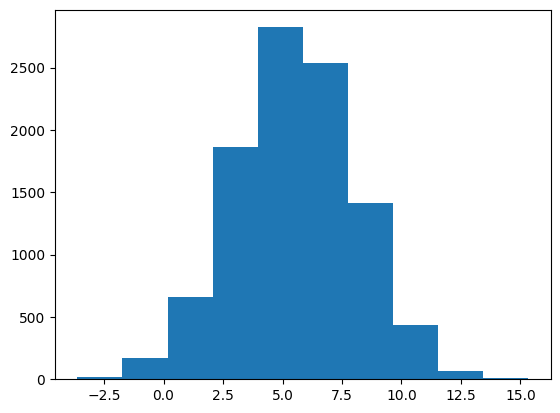

In [41]:
# Para lo que vamos hacer, notar que 'Z' representa una distribución o variable estandarizada.

mean = 5.5
stand_dev = 2.5
stand_dist = np.random.randn(n)

# Z = (X - media) / (desviación estándar) -> N(0,1), X = media + (desviación estándar) * Z

data3 = mean + stand_dev * stand_dist

plt.hist(data3)

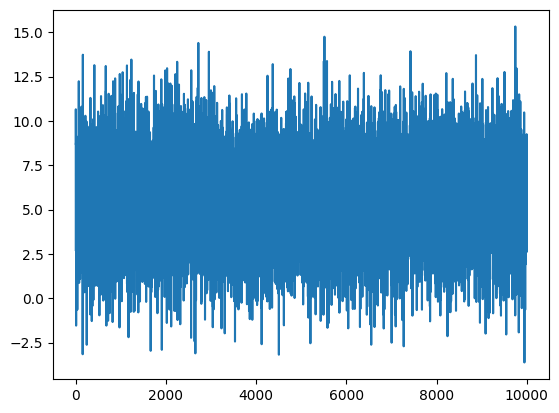

In [42]:
x = range(n)
plt.plot(x, data3)

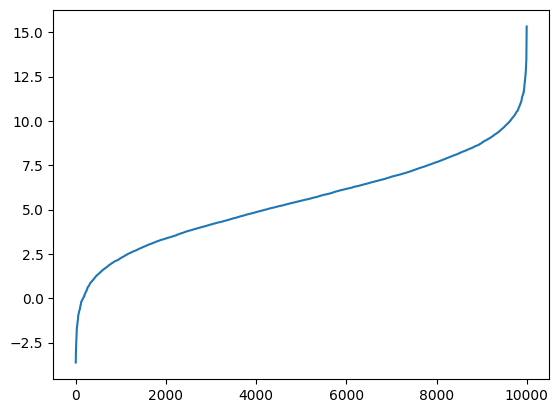

In [43]:
# Visualizamos el gráfico función de la distribución
plt.plot(x,sorted(data3))

In [44]:
'''
Generando distribuciones estándar aleatorias
(en este caso dos listas, cada una representando una distribución)
Caso: 2 listas, de n valores
'''

data4 = np.random.randn(2, n)
data4

array([[ 0.6247363 , -0.75801183, -2.9429535 , ...,  0.37548078,
        -0.67506365,  0.76944375],
       [ 0.5150948 , -0.0868631 ,  0.95674829, ...,  0.19968867,
         0.34904096,  0.67444429]])

(array([   3.,   54.,  355., 1224., 2599., 2980., 1905.,  709.,  153.,
          18.]),
 array([-4.0443183 , -3.27335805, -2.50239779, -1.73143754, -0.96047728,
        -0.18951703,  0.58144322,  1.35240348,  2.12336373,  2.89432399,
         3.66528424]),
 <BarContainer object of 10 artists>)

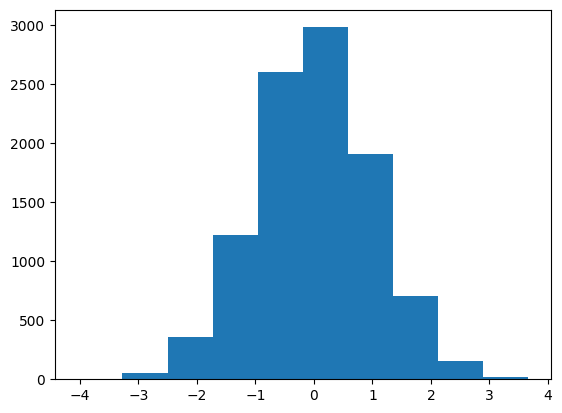

In [45]:
plt.hist(data4[0])

## El Método de Monte Carlo

* Generamos dos números aleatorios uniforme x e y entre 0 y 1 en total 1000 veces.
* Calcularemos $z = x^2 + y^2$:
    * Si $z < 1 \rightarrow$ estamos dentro del círculo.
    * Si $z \geq 1 \rightarrow$ estamos fuera del círculo.
* Calculamos el número total de veces que están dentro del círculo y lo dividimos entre el número total de intentos para obtener una aproximación de la probabilidad de caer dentro del círculo.
* Usamos dicha probabilidad para aproximar el valor de π.
* Repetimos el experimento un número suficiente de veces (por ejemplo 100), para obtener (100) diferentes aproximaciones de π.
* Calculamos el promedio de los 100 experimentos anteriores para dar un valor final de π.

In [48]:
def calculate_pi(n, n_exp):
    data_hist = []
    for i in range(n_exp):
        counter = 0
        for i in range(n):
            x = np.random.random()
            y = np.random.random()
            result = x ** 2 + y **2
            if result < 1:
                counter += 1
        pi_aprox = float((4 * counter) / n)
        data_hist.append(pi_aprox)
    return np.mean(data_hist), plt.hist(data_hist)

(3.1392000000000007,
 (array([ 6., 11., 14., 11., 14., 15., 13., 11.,  4.,  1.]),
  array([2.8  , 2.876, 2.952, 3.028, 3.104, 3.18 , 3.256, 3.332, 3.408,
         3.484, 3.56 ]),
  <BarContainer object of 10 artists>))

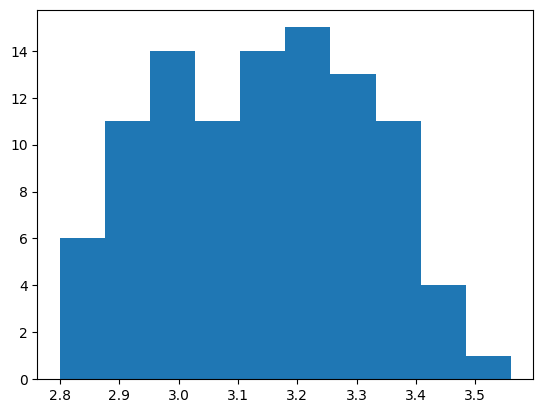

In [50]:
calculate_pi(100,100)

In [51]:
def pi_montecarlo(n, n_exp):
    pi_avg = 0
    pi_value_list = []
    for i in range(n_exp):
        value = 0
        x = np.random.uniform(0,1,n).tolist()
        y = np.random.uniform(0,1,n).tolist()
        for j in range(n):
            z = np.sqrt(x[j] * x[j] + y[j] * y[j])
            if z<=1:
                value += 1
        float_value = float(value)
        pi_value = float_value * 4 / n
        pi_value_list.append(pi_value)
        pi_avg += pi_value

    pi = pi_avg/n_exp

    print(pi)
    fig = plt.hist(pi_value_list)
    return (pi, fig)

3.144159999999984


(3.144159999999984,
 (array([  1.,  10.,  22.,  74., 177., 384., 217.,  99.,  11.,   5.]),
  array([2.44 , 2.568, 2.696, 2.824, 2.952, 3.08 , 3.208, 3.336, 3.464,
         3.592, 3.72 ]),
  <BarContainer object of 10 artists>))

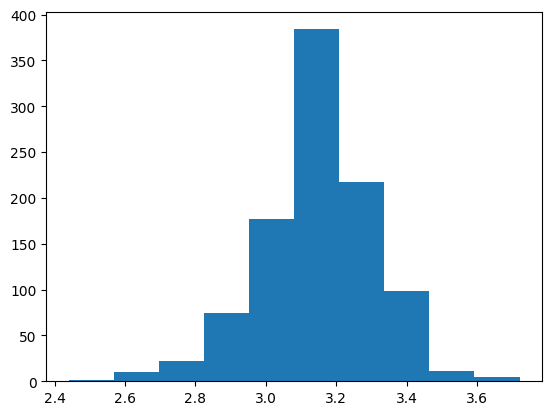

In [52]:
pi_montecarlo(100, 1000)

##Dummy Datasets (conjuntos de datos ficticios).

In [61]:
n = 1000
data5 = pd.DataFrame({
    'A' : np.random.randn(n),
    'B' : 1.5 + 2.5 * np.random.randn(n),
    'C' : np.random.uniform(5, 32, n)
    })

In [67]:
data5.head()

,A,B,C
0,0.219865,3.103912,19.906980
1,-0.609244,-0.290170,10.860034
2,-1.989671,2.390883,10.862792
3,1.607797,5.368058,22.452655
4,-1.533583,0.560917,15.982095


In [68]:
data5.describe()

,A,B,C
count,1000.000000,1000.000000,1000.000000
mean,0.016717,1.426600,18.490482
std,0.990042,2.483668,7.783580
min,-2.767722,-7.188275,5.056865
25%,-0.650260,-0.212752,11.739625
50%,0.018740,1.403502,18.999612
75%,0.697801,3.178934,24.907139
max,3.099454,10.187674,31.999449


(array([ 10.,  43.,  96., 175., 237., 211., 140.,  59.,  24.,   5.]),
 array([-2.76772245, -2.18100477, -1.59428709, -1.00756941, -0.42085174,
         0.16586594,  0.75258362,  1.3393013 ,  1.92601898,  2.51273665,
         3.09945433]),
 <BarContainer object of 10 artists>)

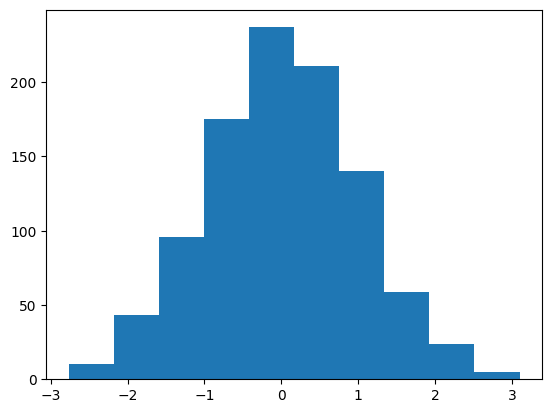

In [69]:
plt.hist(data5["A"])

(array([  5.,  16.,  60., 164., 272., 238., 174.,  61.,   7.,   3.]),
 array([-7.18827516, -5.45068028, -3.71308539, -1.9754905 , -0.23789561,
         1.49969927,  3.23729416,  4.97488905,  6.71248394,  8.45007882,
        10.18767371]),
 <BarContainer object of 10 artists>)

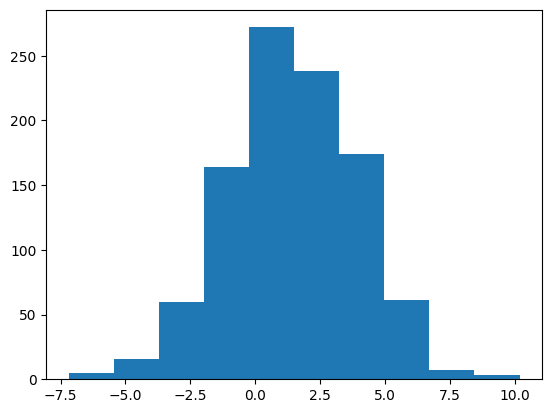

In [70]:
plt.hist(data5["B"])

(array([104., 107.,  82., 108.,  83., 108., 116., 100.,  93.,  99.]),
 array([ 5.0568647 ,  7.75112312, 10.44538154, 13.13963997, 15.83389839,
        18.52815681, 21.22241523, 23.91667365, 26.61093208, 29.3051905 ,
        31.99944892]),
 <BarContainer object of 10 artists>)

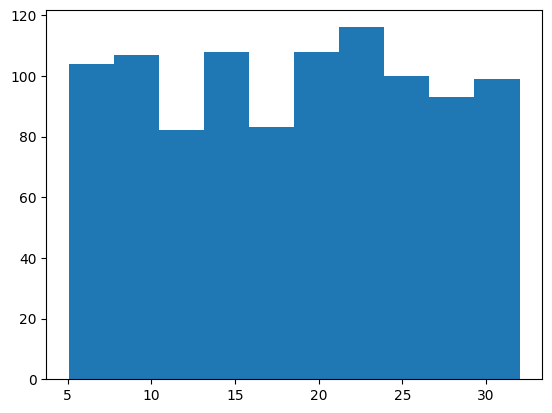

In [71]:
plt.hist(data5["C"])

In [73]:
# Volvamos con datasets del drive:

path6 = "/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/customer-churn-model/Customer Churn Model.txt"
data6 = pd.read_csv(path6)

In [ ]:
data6.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [75]:
column_names = data6.columns.values.tolist()
n6 = len(column_names)
n6

21

In [77]:
new_data6 = pd.DataFrame({
    'Column Name': column_names,
    'A' : np.random.randn(n6),
    'B' : np.random.uniform(0, 1, n6)
    },
    index = range(42, 42 + n6))

In [79]:
new_data6

,Column Name,A,B
42,State,-1.659361,0.567033
43,Account Length,0.719417,0.415996
44,Area Code,-0.017157,0.221423
45,Phone,0.978473,0.227650
46,Int'l Plan,0.071919,0.500912
47,VMail Plan,-0.723296,0.319354
48,VMail Message,-0.469852,0.145497
49,Day Mins,0.753445,0.051416
50,Day Calls,-0.834209,0.910745
51,Day Charge,0.214978,0.101725
